# Predicción de retrasos de entrega con Amazon SageMaker

## Objetivo

Entrenar un modelo de clasificación para estimar la probabilidad de que un pedido de Olist llegue después de la fecha estimada de entrega.

La variable objetivo es:

`is_delayed`

- `0`: pedido entregado a tiempo o antes de la fecha estimada.
- `1`: pedido entregado después de la fecha estimada.

El modelo utilizará únicamente variables disponibles antes de conocer el resultado final de la entrega, con el fin de evitar data leakage.

## Features iniciales

Se utilizarán variables relacionadas con:

- ubicación del cliente;
- categoría principal del producto;
- cantidad de ítems, productos y vendedores;
- precio y costo de flete;
- características físicas promedio de los productos;
- tiempo estimado de entrega;
- mes y día de compra.

Se excluyen variables conocidas después de la entrega, como:

- `actual_delivery_days`
- `delay_days`
- `avg_review_score`
- `review_count`
- `has_review_comment`
- `order_delivered_customer_date`

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

In [2]:
S3_PATH = "s3://aws-olist-data-pipeline/processed/orders_analytics/"

df = pd.read_parquet(S3_PATH)

df.shape
print(df.head())

                           order_id                customer_unique_id  \
0  0005a1a1728c9d785b8e2b08b904576c  639d23421f5517f69d0c3d6e6564cf0e   
1  0005f50442cb953dcd1d21e1fb923495  0782c41380992a5a533489063df0eef6   
2  0008288aa423d2a3f00fcb17cd7d8719  9e4159995424971423b98c4a8bc11529   
3  000f25f4d72195062c040b12dce9a18a  1a6cbc34ea404cb0af7ed74df0999354   
4  001021efaa8636c29475e7734483457d  2193383c470dc9cec894ce78afd0ebd6   

  customer_state  customer_city order_status order_purchase_timestamp  \
0             SP         santos    delivered      2018-03-19 18:40:33   
1             SP        jandira    delivered      2018-07-02 13:59:39   
2             SP        jandira    delivered      2018-02-13 22:10:21   
3             RJ  volta redonda    delivered      2018-03-07 10:33:13   
4             PR       ivaipora    delivered      2018-02-27 09:27:14   

  order_estimated_delivery_date order_delivered_customer_date  purchase_year  \
0                    2018-03-29           

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_unique_id             99441 non-null  object        
 2   customer_state                 99441 non-null  object        
 3   customer_city                  99441 non-null  object        
 4   order_status                   99441 non-null  object        
 5   order_purchase_timestamp       99441 non-null  datetime64[ns]
 6   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 7   order_delivered_customer_date  96476 non-null  datetime64[ns]
 8   purchase_year                  99441 non-null  int32         
 9   purchase_month                 99441 non-null  int32         
 10  purchase_day_of_week           99441 non-null  int32         
 11  item_count     

In [4]:
ml_df = df[df["is_delayed"].notna()].copy()

ml_df.shape

(96476, 27)

In [5]:
class_distribution = (
    ml_df["is_delayed"]
    .value_counts(dropna=False)
    .sort_index()
)

class_distribution

is_delayed
0.0    88649
1.0     7827
Name: count, dtype: int64

In [6]:
class_distribution_pct = (
    ml_df["is_delayed"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_distribution_pct

is_delayed
0.0    91.887101
1.0     8.112899
Name: proportion, dtype: float64

In [7]:
state_analysis = (
    ml_df
    .groupby("customer_state")
    .agg(
        orders=("is_delayed", "size"),
        delay_rate=("is_delayed", "mean"),
    )
    .sort_values("delay_rate", ascending=False)
)

state_analysis

,orders,delay_rate
customer_state,,
AL,397,0.239295
MA,717,0.196653
PI,476,0.159664
CE,1279,0.153245
SE,335,0.152239
BA,3256,0.140356
RJ,12353,0.134704
TO,274,0.127737
PA,946,0.123679


In [8]:
state_analysis.describe()

,orders,delay_rate
count,27.000000,27.000000
mean,3573.185185,0.104442
std,8021.076362,0.050979
min,41.000000,0.028807
25%,366.000000,0.063333
50%,886.000000,0.107972
75%,2668.000000,0.131221
max,40495.000000,0.239295


In [9]:
category_analysis = (
    ml_df
    .groupby("main_product_category", dropna=False)
    .agg(
        orders=("is_delayed", "size"),
        delay_rate=("is_delayed", "mean"),
    )
    .sort_values("orders")
)

category_analysis.head(20)

,orders,delay_rate
main_product_category,,
security_and_services,2,0.000000
fashion_childrens_clothes,6,0.000000
cds_dvds_musicals,12,0.000000
la_cuisine,13,0.000000
arts_and_craftmanship,22,0.090909
home_comfort_2,22,0.181818
diapers_and_hygiene,25,0.040000
fashion_sport,25,0.080000
flowers,28,0.035714


In [10]:
category_analysis["orders"].describe()

count      72.000000
mean     1339.944444
std      2194.521141
min         2.000000
25%        87.000000
50%       241.000000
75%      1454.750000
max      9203.000000
Name: orders, dtype: float64

In [11]:
(category_analysis["orders"] < 100).sum()

20

In [12]:
NUMERICAL_FEATURES_EDA = [
    "item_count",
    "product_count",
    "seller_count",
    "total_price",
    "total_freight",
    "avg_product_weight_g",
    "avg_product_volume_cm3",
    "estimated_delivery_days",
]

ml_df[NUMERICAL_FEATURES_EDA].describe().T

,count,mean,std,min,25%,50%,75%,max
item_count,96476.0,1.142212,0.538816,1.00,1.00,1.00,1.00,21.00
product_count,96476.0,1.038548,0.227965,1.00,1.00,1.00,1.00,8.00
seller_count,96476.0,1.013900,0.123538,1.00,1.00,1.00,1.00,5.00
total_price,96476.0,137.038176,209.047091,0.85,45.90,86.50,149.90,13440.00
total_freight,96476.0,22.785442,21.559394,0.00,13.85,17.17,24.02,1794.96
avg_product_weight_g,96460.0,2098.206807,3744.917366,0.00,300.00,700.00,1800.00,40425.00
avg_product_volume_cm3,96460.0,15152.772820,23217.383268,168.00,2816.00,6400.00,18228.00,296208.00
estimated_delivery_days,96476.0,24.374217,8.760837,3.00,19.00,24.00,29.00,156.00


In [13]:
ml_df[NUMERICAL_FEATURES_EDA].skew().sort_values(
    ascending=False
)

total_freight              12.277150
total_price                 9.885592
seller_count                9.870587
product_count               8.070318
item_count                  7.557531
avg_product_volume_cm3      4.077306
avg_product_weight_g        3.610720
estimated_delivery_days     0.906129
dtype: float64

## Desbalance de clases

La clase positiva (`is_delayed = 1`) representa aproximadamente el 8% de los pedidos entregados. Por esta razón, accuracy no será suficiente para evaluar el modelo. Se priorizarán métricas como:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- matriz de confusión

In [14]:
FEATURES = [
    "customer_state",
    "main_product_category",
    "item_count",
    "product_count",
    "seller_count",
    "total_price",
    "total_freight",
    "avg_product_weight_g",
    "avg_product_volume_cm3",
    "estimated_delivery_days",
    "purchase_month",
    "purchase_day_of_week",
]

TARGET = "is_delayed"

model_df = ml_df[FEATURES + [TARGET]].copy()

model_df.head()

,customer_state,main_product_category,item_count,product_count,seller_count,total_price,total_freight,avg_product_weight_g,avg_product_volume_cm3,estimated_delivery_days,purchase_month,purchase_day_of_week,is_delayed
0,SP,health_beauty,1.0,1.0,1.0,145.95,11.65,2000.0,5760.0,10,3,2,1.0
1,SP,books_technical,1.0,1.0,1.0,53.99,11.40,850.0,1827.0,21,7,2,0.0
2,SP,garden_tools,2.0,1.0,1.0,99.80,26.74,1650.0,19800.0,21,2,3,0.0
3,RJ,office_furniture,1.0,1.0,1.0,119.99,44.40,9375.0,56430.0,35,3,4,0.0
4,PR,fashion_bags_accessories,1.0,1.0,1.0,49.00,15.10,250.0,640.0,24,2,3,0.0


In [15]:
missing_values = (
    model_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values

main_product_category      1380
avg_product_weight_g         16
avg_product_volume_cm3       16
customer_state                0
item_count                    0
seller_count                  0
product_count                 0
total_freight                 0
total_price                   0
estimated_delivery_days       0
purchase_month                0
purchase_day_of_week          0
is_delayed                    0
dtype: int64

## train / validation / test

Antes de codificar categóricas, hagamos la división para evitar contaminación entre conjuntos.

In [16]:
from sklearn.model_selection import train_test_split

X = model_df[FEATURES].copy()
y = model_df[TARGET].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42,
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
)

print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

print("\nTarget distribution")
print("Train:")
print(y_train.value_counts(normalize=True))
print("\nValidation:")
print(y_validation.value_counts(normalize=True))
print("\nTest:")
print(y_test.value_counts(normalize=True))

Train: (67533, 12)
Validation: (14471, 12)
Test: (14472, 12)

Target distribution
Train:
is_delayed
0    0.918869
1    0.081131
Name: proportion, dtype: float64

Validation:
is_delayed
0    0.918872
1    0.081128
Name: proportion, dtype: float64

Test:
is_delayed
0    0.918878
1    0.081122
Name: proportion, dtype: float64


## Preprocesamiento

Las variables categóricas se transforman mediante One-Hot Encoding y las variables numéricas se conservan en su escala original.

El preprocesamiento se ajusta únicamente con el conjunto de entrenamiento para evitar fuga de información entre train, validation y test.

Agrupar categorias raras

In [17]:
category_counts = (
    X_train["main_product_category"]
    .value_counts()
)

frequent_categories = category_counts[
    category_counts >= 100
].index

for dataset in [
    X_train,
    X_validation,
    X_test,
]:
    dataset["main_product_category"] = (
        dataset["main_product_category"]
        .fillna("unknown")
        .where(
            dataset["main_product_category"].isin(
                frequent_categories
            ),
            "other",
        )
    )

In [18]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [19]:
CATEGORICAL_FEATURES = [
    "customer_state",
    "main_product_category",
    "purchase_month",
    "purchase_day_of_week",
]

NUMERICAL_FEATURES = [
    "item_count",
    "product_count",
    "seller_count",
    "total_price",
    "total_freight",
    "avg_product_weight_g",
    "avg_product_volume_cm3",
    "estimated_delivery_days",
]

In [20]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
            ),
        ),
    ]
)

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES,
        ),
        (
            "numerical",
            numerical_pipeline,
            NUMERICAL_FEATURES,
        ),
    ]
)

In [21]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count
scale_pos_weight

11.325789377623654

In [22]:
## XGBoost

In [23]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model),
    ]
)

In [24]:
model_pipeline.fit(
    X_train,
    y_train,
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

y_val_pred = model_pipeline.predict(X_validation)

y_val_proba = model_pipeline.predict_proba(
    X_validation
)[:, 1]

print("Evaluación sobre el test de validacion")
print(
    classification_report(
        y_validation,
        y_val_pred,
        digits=4,
    )
)

print(
    "Confusion Matrix:\n",
    confusion_matrix(
        y_validation,
        y_val_pred,
    ),
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_validation,
            y_val_proba,
        ),
        4,
    ),
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_validation,
            y_val_proba,
        ),
        4,
    ),
)

Evaluación sobre el test de validacion
              precision    recall  f1-score   support

           0     0.9610    0.7539    0.8450     13297
           1     0.1899    0.6533    0.2943      1174

    accuracy                         0.7458     14471
   macro avg     0.5754    0.7036    0.5696     14471
weighted avg     0.8984    0.7458    0.8003     14471

Confusion Matrix:
 [[10025  3272]
 [  407   767]]
ROC-AUC: 0.7719
PR-AUC: 0.2809


* Recall de retrasados: 65%
* Precision de retrasados: 19%
* F1: 0,30
* ROC-AUC: 0,77
*PR-AUC: 0,28

3272 pedidos a tiempo son clasificados como riesgo de retraso


In [26]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve


)

results = []

for threshold in [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
]:

    y_pred_threshold = (
        y_val_proba >= threshold
    ).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation,
            y_pred_threshold,
        ),
        "recall": recall_score(
            y_validation,
            y_pred_threshold,
        ),
        "f1": f1_score(
            y_validation,
            y_pred_threshold,
        ),
    })

pd.DataFrame(results)

,threshold,precision,recall,f1
0,0.50,0.189898,0.653322,0.294264
1,0.55,0.212029,0.594549,0.312584
2,0.60,0.234686,0.522147,0.323825
3,0.65,0.271611,0.452300,0.339406
4,0.70,0.303661,0.360307,0.329568


In [27]:
precision, recall, thresholds = precision_recall_curve(
    y_validation,
    y_val_proba,
)

threshold_df = pd.DataFrame({
    "threshold": np.append(thresholds, np.nan),
    "precision": precision,
    "recall": recall,
})

threshold_df["f1"] = (
    2
    * threshold_df["precision"]
    * threshold_df["recall"]
    / (
        threshold_df["precision"]
        + threshold_df["recall"]
    )
)

threshold_df.sort_values(
    "f1",
    ascending=False,
).head(10)

,threshold,precision,recall,f1
12470,0.649796,0.272078,0.454003,0.340249
12469,0.649774,0.271939,0.454003,0.340140
12468,0.649705,0.271800,0.454003,0.340032
12479,0.650272,0.272308,0.452300,0.339949
12467,0.649636,0.271662,0.454003,0.339923
12478,0.650202,0.272168,0.452300,0.339840
12472,0.649904,0.271845,0.453152,0.339828
12466,0.649619,0.271523,0.454003,0.339815
12477,0.650138,0.272029,0.452300,0.339731
12471,0.649852,0.271706,0.453152,0.339719


## Evaluación final sobre test

Después de seleccionar el modelo, el preprocesamiento y el threshold utilizando únicamente los conjuntos de entrenamiento y validación, se realiza una evaluación final sobre el conjunto de test.

El threshold seleccionado es `0.65`, ya que presentó el mejor equilibrio entre precision y recall en el conjunto de validación.

In [28]:
FINAL_THRESHOLD = 0.65

y_test_proba = model_pipeline.predict_proba(
    X_test
)[:, 1]

y_test_pred = (
    y_test_proba >= FINAL_THRESHOLD
).astype(int)

In [29]:
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
    )
)

print(
    "Confusion Matrix:\n",
    confusion_matrix(
        y_test,
        y_test_pred,
    ),
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            y_test_proba,
        ),
        4,
    ),
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            y_test_proba,
        ),
        4,
    ),
)

              precision    recall  f1-score   support

           0     0.9486    0.8871    0.9168     13298
           1     0.2628    0.4557    0.3333      1174

    accuracy                         0.8521     14472
   macro avg     0.6057    0.6714    0.6251     14472
weighted avg     0.8930    0.8521    0.8695     14472

Confusion Matrix:
 [[11797  1501]
 [  639   535]]
ROC-AUC: 0.7812
PR-AUC: 0.2597


In [30]:
test_metrics = {
    "roc_auc": roc_auc_score(
        y_test,
        y_test_proba,
    ),
    "pr_auc": average_precision_score(
        y_test,
        y_test_proba,
    ),
    "precision": precision_score(
        y_test,
        y_test_pred,
    ),
    "recall": recall_score(
        y_test,
        y_test_pred,
    ),
    "f1": f1_score(
        y_test,
        y_test_pred,
    ),
    "threshold": FINAL_THRESHOLD,
}

pd.Series(test_metrics)

roc_auc      0.781160
pr_auc       0.259665
precision    0.262770
recall       0.455707
f1           0.333333
threshold    0.650000
dtype: float64

ROC-AUC = 0.78
PR-AUC = 0.25
Precision clase retrasada = 0.26
Recall clase retrasada = 0.45
F1 clase retrasada = 0.33
Threshold = 0.65

Esto es bastante consistente con validation, donde el F1 estaba alrededor de 0.34. El ROC-AUC incluso subió un poco. El PR-AUC bajó de ~0.281 a ~0.260, pero sigue muy por encima de la prevalencia base de ~8.1%, así que el modelo mantiene señal predictiva real.


El modelo permite priorizar pedidos con mayor riesgo logístico antes de conocer el resultado final de la entrega. Con un threshold de 0.65, identifica aproximadamente el 46% de los pedidos retrasados y alcanza un ROC-AUC de 0.78 sobre datos no utilizados durante el desarrollo.

## Importancia de variables del modelo final

Se analiza la importancia de las variables utilizadas por el modelo XGBoost final.

Debido al One-Hot Encoding, las variables categóricas se expanden en múltiples columnas. Por esta razón se revisa tanto la importancia individual de las variables transformadas como la importancia agregada por variable original.

In [31]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]
fitted_model = model_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": fitted_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,feature,importance
0,categorical__purchase_month_3,0.069615
1,categorical__purchase_month_6,0.061009
2,categorical__purchase_month_11,0.045419
3,categorical__purchase_month_2,0.042413
4,categorical__customer_state_SP,0.031493
5,categorical__customer_state_RJ,0.028603
6,categorical__customer_state_MG,0.026710
7,categorical__purchase_month_7,0.024433
8,categorical__customer_state_PR,0.021394
9,numerical__seller_count,0.019862


In [32]:
feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace("categorical__", "", regex=False)
    .str.replace("numerical__", "", regex=False)
)

feature_importance.head(20)

,feature,importance
0,purchase_month_3,0.069615
1,purchase_month_6,0.061009
2,purchase_month_11,0.045419
3,purchase_month_2,0.042413
4,customer_state_SP,0.031493
5,customer_state_RJ,0.028603
6,customer_state_MG,0.026710
7,purchase_month_7,0.024433
8,customer_state_PR,0.021394
9,seller_count,0.019862


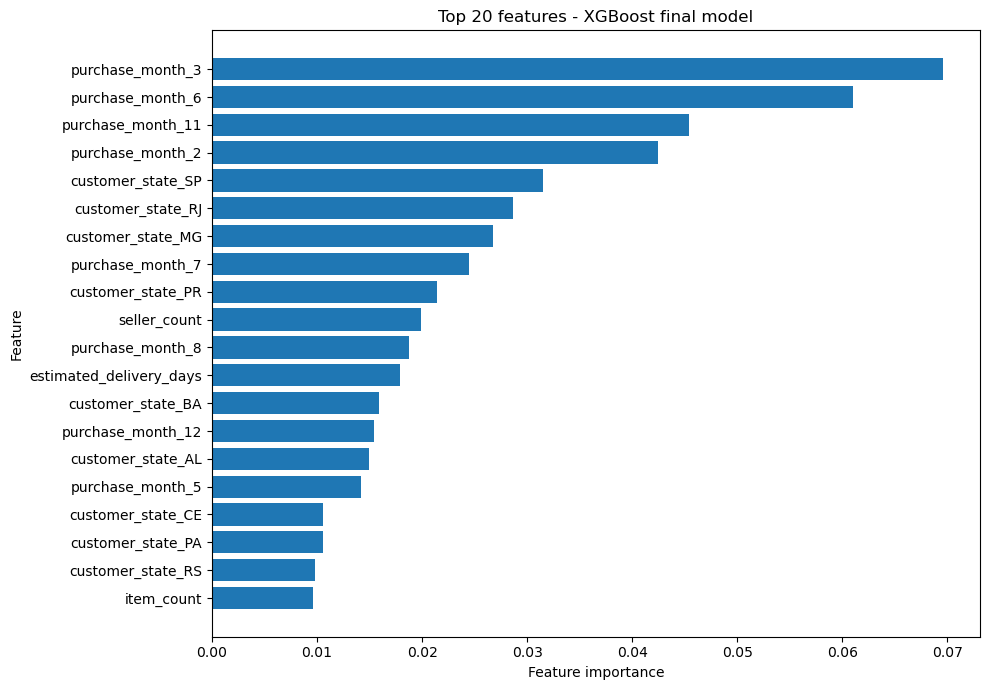

In [33]:
import matplotlib.pyplot as plt

top_features = (
    feature_importance
    .head(20)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 20 features - XGBoost final model")

plt.tight_layout()
plt.show()

In [34]:
grouped_importance = feature_importance.copy()

def get_original_feature(feature):
    if feature.startswith("customer_state_"):
        return "customer_state"

    if feature.startswith("main_product_category_"):
        return "main_product_category"

    if feature.startswith("purchase_month_"):
        return "purchase_month"

    if feature.startswith("purchase_day_of_week_"):
        return "purchase_day_of_week"

    return feature


grouped_importance["original_feature"] = (
    grouped_importance["feature"]
    .apply(get_original_feature)
)

grouped_importance = (
    grouped_importance
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

grouped_importance

,original_feature,importance
0,purchase_month,0.322478
1,customer_state,0.285733
2,main_product_category,0.271102
3,purchase_day_of_week,0.036298
4,seller_count,0.019862
5,estimated_delivery_days,0.017890
6,item_count,0.009607
7,total_freight,0.009533
8,product_count,0.007806
9,avg_product_volume_cm3,0.006733


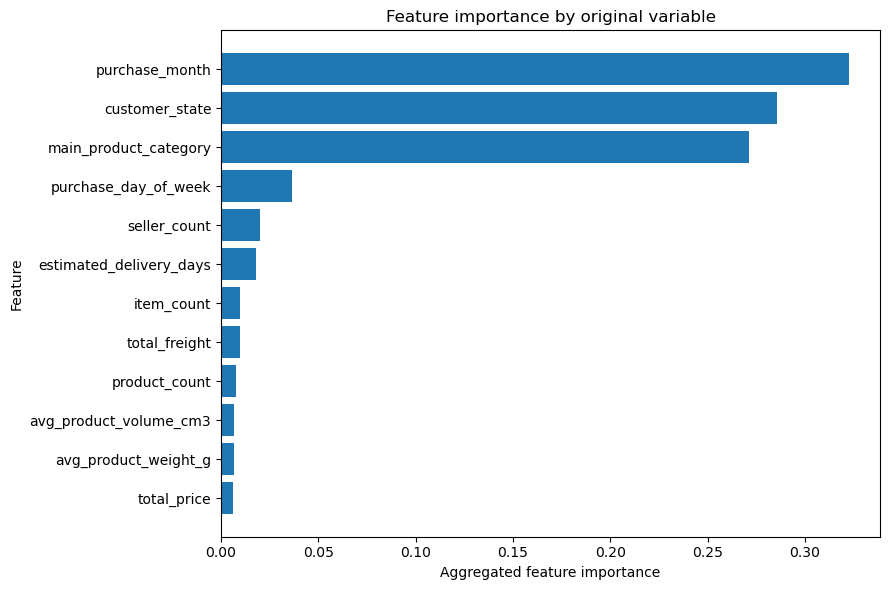

In [35]:
plot_importance = (
    grouped_importance
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_importance["original_feature"],
    plot_importance["importance"],
)

plt.xlabel("Aggregated feature importance")
plt.ylabel("Feature")
plt.title("Feature importance by original variable")

plt.tight_layout()
plt.show()

### Interpretación

La importancia de variables del modelo final muestra que las variables con mayor contribución agregada son:

- purchase_month
- customer_state
- main_product_category

Esto sugiere que el riesgo de retraso presenta patrones asociados con la época del año, la ubicación geográfica del cliente y el tipo de producto comprado.

También aparecen variables operativas como **seller_count, estimated_delivery_days e item_count,** aunque con menor importancia relativa.

Estas importancias representan el uso de las variables dentro de los árboles de XGBoost y no deben interpretarse como relaciones causales.

## Preparación de datos para SageMaker Training

El modelo inicial fue desarrollado y validado dentro del entorno de JupyterLab.

A continuación, el procesamiento aprendido sobre el conjunto de entrenamiento se utiliza para generar datasets numéricos que serán almacenados en Amazon S3 y utilizados por un SageMaker Training Job administrado.

#### Transformar train y validation

Como model_v2 contiene preprocesamiento + XGBoost, obtenemos solamente el preprocesador entrenado:

In [36]:
fitted_preprocessor = model_pipeline.named_steps[
    "preprocessor"
]

X_train_processed = fitted_preprocessor.transform(
    X_train
)

X_validation_processed = fitted_preprocessor.transform(
    X_validation
)

X_test_processed = fitted_preprocessor.transform(
    X_test
)

print(
    X_train_processed.shape,
    X_validation_processed.shape,
    X_test_processed.shape,
)

(67533, 102) (14471, 102) (14472, 102)


## Exportación de datasets para SageMaker Training

Los conjuntos preprocesados se convierten a formato CSV numérico para utilizarlos como entrada de un SageMaker Training Job con XGBoost.

En el formato de entrenamiento supervisado, la primera columna corresponde a la variable objetivo `is_delayed`.

In [37]:
from scipy import sparse

def build_sagemaker_dataframe(X_processed, y):
    if sparse.issparse(X_processed):
        X_processed = X_processed.toarray()

    df_processed = pd.DataFrame(X_processed)
    df_processed.insert(
        0,
        "label",
        y.reset_index(drop=True),
    )

    return df_processed

In [38]:
train_sagemaker = build_sagemaker_dataframe(
    X_train_processed,
    y_train,
)

validation_sagemaker = build_sagemaker_dataframe(
    X_validation_processed,
    y_validation,
)

test_sagemaker = build_sagemaker_dataframe(
    X_test_processed,
    y_test,
)

In [39]:
print("Train:", train_sagemaker.shape)
print("Validation:", validation_sagemaker.shape)
print("Test:", test_sagemaker.shape)

Train: (67533, 103)
Validation: (14471, 103)
Test: (14472, 103)


In [40]:
train_sagemaker.head()

,label,0,1,2,3,4,5,6,7,8,...,92,93,94,95,96,97,98,99,100,101
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,49.9,11.85,100.0,6480.0,20.0
1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,124.0,13.77,8767.0,114304.0,13.0
2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,179.0,16.88,3300.0,36000.0,25.0
3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,1.0,69.8,26.74,3700.0,32384.0,17.0
4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,109.9,20.01,9400.0,56250.0,35.0


In [41]:
train_sagemaker.iloc[:, 0].value_counts()

label
0    62054
1     5479
Name: count, dtype: int64

In [42]:
import os

os.makedirs("data/sagemaker", exist_ok=True)

train_path = "data/sagemaker/train.csv"
validation_path = "data/sagemaker/validation.csv"
test_path = "data/sagemaker/test.csv"

train_sagemaker.to_csv(
    train_path,
    index=False,
    header=False,
)

validation_sagemaker.to_csv(
    validation_path,
    index=False,
    header=False,
)

test_sagemaker.to_csv(
    test_path,
    index=False,
    header=False,
)

In [43]:
for path in [
    train_path,
    validation_path,
    test_path,
]:
    print(
        path,
        round(os.path.getsize(path) / 1024 / 1024, 2),
        "MB",
    )

data/sagemaker/train.csv 27.08 MB
data/sagemaker/validation.csv 5.8 MB
data/sagemaker/test.csv 5.8 MB


In [44]:
import boto3

s3 = boto3.client("s3")

BUCKET = "aws-olist-data-pipeline"

s3.upload_file(
    train_path,
    BUCKET,
    "ml/train/train.csv",
)

s3.upload_file(
    validation_path,
    BUCKET,
    "ml/validation/validation.csv",
)

s3.upload_file(
    test_path,
    BUCKET,
    "ml/test/test.csv",
)

print("Datasets uploaded to S3")

Datasets uploaded to S3


In [45]:
response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix="ml/",
)

for obj in response.get("Contents", []):
    print(obj["Key"])

ml/test/test.csv
ml/train/train.csv
ml/validation/validation.csv


## Entrenamiento administrado con Amazon SageMaker

Los datasets preprocesados se encuentran almacenados en Amazon S3.

Se utilizará el contenedor administrado de XGBoost de SageMaker para entrenar el modelo utilizando los canales:

- `train`
- `validation`

El conjunto `test` permanece reservado y no participa en el entrenamiento.

### 1. Crear sesión, región y obtener el rol

In [46]:
import sagemaker
import boto3

from sagemaker.core import image_uris
from sagemaker.train.configs import InputData

region = boto3.Session().region_name

print("Region:", region)

xgboost_image = image_uris.retrieve(
    framework="xgboost",
    region=region,
    version="3.2-0",
)

print("XGBoost image:")
print(xgboost_image)

sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Region: us-east-1
XGBoost image:
683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:3.2-0


In [47]:
train_s3_uri = (
    "s3://aws-olist-data-pipeline/ml/train/"
)

validation_s3_uri = (
    "s3://aws-olist-data-pipeline/ml/validation/"
)

model_output_s3 = (
    "s3://aws-olist-data-pipeline/ml/model/"
)

In [48]:
train_input = InputData(
    channel_name="train",
    data_source=train_s3_uri,
    content_type="text/csv",
)

validation_input = InputData(
    channel_name="validation",
    data_source=validation_s3_uri,
    content_type="text/csv",
)

In [49]:
from sagemaker.train import ModelTrainer
from sagemaker.train.configs import Compute, OutputDataConfig
from sagemaker.core.helper.session_helper import get_execution_role

In [50]:
compute = Compute(
    instance_type="ml.m5.large",
    instance_count=1,
    volume_size_in_gb=10,
)

output_config = OutputDataConfig(
    s3_output_path="s3://aws-olist-data-pipeline/ml/model/"
)

In [51]:
hyperparameters = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "max_depth": "5",
    "eta": "0.05",
    "subsample": "0.8",
    "colsample_bytree": "0.8",
    "num_round": "300",
    "scale_pos_weight": str(scale_pos_weight),
}

In [52]:
model_trainer = ModelTrainer(
    training_image=xgboost_image,
    role=get_execution_role(),
    compute=compute,
    output_data_config=output_config,
    hyperparameters=hyperparameters,
    base_job_name="olist-delay-xgboost",
)

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix


In [53]:
model_trainer.train(
    input_data_config=[
        train_input,
        validation_input,
    ]
)

sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment
sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


Output()

In [56]:
sm_client = boto3.client(
    "sagemaker",
    region_name=region,
)

jobs = sm_client.list_training_jobs(
    NameContains="olist-delay-xgboost",
    SortBy="CreationTime",
    SortOrder="Descending",
    MaxResults=1,
)

training_job_name = jobs["TrainingJobSummaries"][0][
    "TrainingJobName"
]

training_job_name

'olist-delay-xgboost-20260919211739'

In [57]:
job_details = sm_client.describe_training_job(
    TrainingJobName=training_job_name
)

print(
    "Training job:",
    job_details["TrainingJobName"]
)

print(
    "Status:",
    job_details["TrainingJobStatus"]
)

print(
    "Model artifact:",
    job_details["ModelArtifacts"]["S3ModelArtifacts"]
)

Training job: olist-delay-xgboost-20260919211739
Status: Completed
Model artifact: s3://aws-olist-data-pipeline/ml/model/olist-delay-xgboost-20260919211739/output/model.tar.gz


In [58]:
for metric in job_details.get(
    "FinalMetricDataList",
    []
):
    print(
        metric["MetricName"],
        metric["Value"],
    )

validation:auc 0.7722300291061401
train:auc 0.8452900052070618


## SageMaker Training Job

El modelo final se entrenó utilizando un Amazon SageMaker Training Job con el contenedor administrado de XGBoost.

Los conjuntos de entrenamiento y validación fueron almacenados en Amazon S3 y utilizados como canales de entrada del job.

El entrenamiento se ejecutó en una instancia `ml.m5.large`. Al finalizar, SageMaker almacenó automáticamente el artefacto entrenado `model.tar.gz` en Amazon S3.

Esto permite separar el entorno utilizado para experimentación del cómputo administrado utilizado para el entrenamiento del modelo.

### Resultado del entrenamiento

El SageMaker Training Job finalizó correctamente y generó el artefacto del modelo en Amazon S3.

Métricas obtenidas:

- Train ROC-AUC: `0.8453`
- Validation ROC-AUC: `0.7722`

El desempeño de validación es consistente con el obtenido durante la experimentación local (`ROC-AUC ≈ 0.772`), lo que confirma que el entrenamiento administrado reproduce adecuadamente el pipeline desarrollado en el notebook.

El artefacto entrenado fue almacenado automáticamente por SageMaker como `model.tar.gz` en Amazon S3.

### Preparando test sin tarjet

In [60]:
from scipy import sparse

X_test_inference = X_test_processed

if sparse.issparse(X_test_inference):
    X_test_inference = X_test_inference.toarray()

test_inference_df = pd.DataFrame(
    X_test_inference
)

test_inference_df.shape

(14472, 102)

In [61]:
inference_path = (
    "data/sagemaker/test_inference.csv"
)

test_inference_df.to_csv(
    inference_path,
    index=False,
    header=False,
)

In [62]:
s3.upload_file(
    inference_path,
    BUCKET,
    "ml/inference/test_inference.csv",
)

print(
    "s3://aws-olist-data-pipeline/"
    "ml/inference/test_inference.csv"
)

s3://aws-olist-data-pipeline/ml/inference/test_inference.csv


## Inferencia batch con SageMaker

Se utiliza el modelo entrenado por SageMaker para ejecutar inferencia sobre el conjunto de test mediante Batch Transform.

Este enfoque permite generar predicciones sin desplegar un endpoint persistente.

create_model
→ create_transform_job
→ monitor del job
→ descarga de predicciones
→ métricas finales

In [63]:
import time
import boto3

sm_client = boto3.client(
    "sagemaker",
    region_name=region,
)

timestamp = time.strftime("%Y%m%d-%H%M%S")

model_name = f"olist-delay-xgboost-model-{timestamp}"

model_artifact = (
    "s3://aws-olist-data-pipeline/ml/model/"
    "olist-delay-xgboost-20260919211739/"
    "output/model.tar.gz"
)

sm_client.create_model(
    ModelName=model_name,
    PrimaryContainer={
        "Image": xgboost_image,
        "ModelDataUrl": model_artifact,
    },
    ExecutionRoleArn=get_execution_role(),
)

print(model_name)

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
olist-delay-xgboost-model-20260919-213826


In [ ]:
transform_job_name = (
    f"olist-delay-batch-{timestamp}"
)

batch_input = (
    "s3://aws-olist-data-pipeline/"
    "ml/inference/test_inference.csv"
)

batch_output = (
    "s3://aws-olist-data-pipeline/"
    "ml/predictions/"
)

sm_client.create_transform_job(
    TransformJobName=transform_job_name,
    ModelName=model_name,
    BatchStrategy="MultiRecord",
    TransformInput={
        "DataSource": {
            "S3DataSource": {
                "S3DataType": "S3Prefix",
                "S3Uri": batch_input,
            }
        },
        "ContentType": "text/csv",
        "SplitType": "Line",
    },
    TransformOutput={
        "S3OutputPath": batch_output,
        "Accept": "text/csv",
        "AssembleWith": "Line",
    },
    TransformResources={
        "InstanceType": "ml.m5.large",
        "InstanceCount": 1,
    },
)

print(transform_job_name)

In [65]:
while True:
    response = sm_client.describe_transform_job(
        TransformJobName=transform_job_name
    )

    status = response["TransformJobStatus"]

    print(status)

    if status in [
        "Completed",
        "Failed",
        "Stopped",
    ]:
        break

    time.sleep(30)

InProgress
InProgress
InProgress
InProgress
InProgress
InProgress
InProgress
InProgress
Completed


## Evaluación del modelo entrenado en SageMaker

Las probabilidades generadas mediante SageMaker Batch Transform se recuperan desde Amazon S3 y se comparan con las etiquetas reales del conjunto de test.

De esta forma se evalúa el artefacto producido por el Training Job administrado, y no únicamente el modelo entrenado localmente durante la experimentación.

In [66]:
response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix="ml/predictions/",
)

for obj in response.get("Contents", []):
    print(
        obj["Key"],
        obj["Size"],
    )

ml/predictions/test_inference.csv.out 280214


In [67]:
import io

prediction_key = (
    "ml/predictions/test_inference.csv.out"
)

prediction_object = s3.get_object(
    Bucket=BUCKET,
    Key=prediction_key,
)

prediction_content = (
    prediction_object["Body"]
    .read()
    .decode("utf-8")
)

print(prediction_content[:500])

0.8439090847969055
0.3248043358325958
0.23147855699062347
0.6433392763137817
0.465962678194046
0.5298747420310974
0.3103272318840027
0.26169532537460327
0.2183847725391388
0.4785119295120239
0.3394138514995575
0.19837620854377747
0.2773303985595703
0.22832362353801727
0.6934282183647156
0.4381617307662964
0.7899694442749023
0.36057430505752563
0.6850396394729614
0.3488447964191437
0.4345611333847046
0.18748757243156433
0.16611754894256592
0.08467035740613937
0.1020498126745224
0.561479389667511



In [68]:
sagemaker_predictions = np.array(
    [
        float(value)
        for value in prediction_content.strip().splitlines()
    ]
)

print(
    "Predictions:",
    sagemaker_predictions.shape
)

print(
    sagemaker_predictions[:10]
)

Predictions: (14472,)
[0.84390908 0.32480434 0.23147856 0.64333928 0.46596268 0.52987474
 0.31032723 0.26169533 0.21838477 0.47851193]


In [69]:
FINAL_THRESHOLD = 0.65
sagemaker_test_pred = (
    sagemaker_predictions >= FINAL_THRESHOLD
).astype(int)


In [70]:
print(
    classification_report(
        y_test,
        sagemaker_test_pred,
        digits=4,
    )
)

print(
    "Confusion Matrix:\n",
    confusion_matrix(
        y_test,
        sagemaker_test_pred,
    ),
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            sagemaker_predictions,
        ),
        4,
    ),
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            sagemaker_predictions,
        ),
        4,
    ),
)

              precision    recall  f1-score   support

           0     0.9477    0.8881    0.9169     13298
           1     0.2597    0.4446    0.3279      1174

    accuracy                         0.8521     14472
   macro avg     0.6037    0.6664    0.6224     14472
weighted avg     0.8919    0.8521    0.8691     14472

Confusion Matrix:
 [[11810  1488]
 [  652   522]]
ROC-AUC: 0.7798
PR-AUC: 0.2588


In [71]:
sagemaker_test_metrics = pd.Series(
    {
        "roc_auc": roc_auc_score(
            y_test,
            sagemaker_predictions,
        ),
        "pr_auc": average_precision_score(
            y_test,
            sagemaker_predictions,
        ),
        "precision": precision_score(
            y_test,
            sagemaker_test_pred,
        ),
        "recall": recall_score(
            y_test,
            sagemaker_test_pred,
        ),
        "f1": f1_score(
            y_test,
            sagemaker_test_pred,
        ),
        "threshold": FINAL_THRESHOLD,
    }
)

sagemaker_test_metrics

roc_auc      0.779806
pr_auc       0.258756
precision    0.259701
recall       0.444634
f1           0.327889
threshold    0.650000
dtype: float64

In [72]:
comparison = pd.DataFrame(
    {
        "Local XGBoost": test_metrics,
        "SageMaker XGBoost": sagemaker_test_metrics,
    }
)

comparison

,Local XGBoost,SageMaker XGBoost
roc_auc,0.781160,0.779806
pr_auc,0.259665,0.258756
precision,0.262770,0.259701
recall,0.455707,0.444634
f1,0.333333,0.327889
threshold,0.650000,0.650000


## Conclusiones del modelo

Se desarrolló un modelo XGBoost para estimar el riesgo de retraso de los pedidos utilizando únicamente información disponible antes de conocer el resultado final de la entrega.

El modelo entrenado mediante Amazon SageMaker obtuvo sobre el conjunto de test:

- ROC-AUC: `0.7798`
- PR-AUC: `0.2588`
- Precision: `0.2597`
- Recall: `0.4446`
- F1-score: `0.3279`
- Classification threshold: `0.65`

Los resultados son muy similares a los obtenidos durante la experimentación local, lo que indica que el entrenamiento administrado en SageMaker reprodujo correctamente el comportamiento del modelo desarrollado en el notebook.

La variable objetivo presenta un fuerte desbalance, con aproximadamente el 8% de pedidos retrasados. Por esta razón, métricas como PR-AUC, recall y F1-score fueron consideradas más relevantes que accuracy.

El análisis de importancia de variables mostró que los principales patrones utilizados por el modelo están relacionados con el mes de compra, el estado del cliente y la categoría principal del producto.

El flujo final de Machine Learning utiliza Amazon S3 para almacenar los datasets y artefactos, SageMaker Training Jobs para el entrenamiento administrado y SageMaker Batch Transform para realizar inferencia sin mantener un endpoint activo.